# Email Spam Classification (Text Data)
### Naive Bayes with CountVectorizer & TF-IDF
**Goal:** Classify emails as **Spam** or **Ham** using Multinomial and Bernoulli Naive Bayes.

---
## Import Required Libraries

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Scikit-learn: Naive Bayes models
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

# Scikit-learn: train/test split and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Load the Dataset

In [22]:

df = pd.read_csv('spam_and_ham_classification.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 9989 rows, 2 columns


,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...


---
## Explore the Dataset

In [23]:
# Check dataset shape and basic info
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (9989, 2)

Column names: ['label', 'text']

Data types:
label    object
text     object
dtype: object

Missing values:
label    0
text     0
dtype: int64


Class distribution:
label
ham     5294
spam    4695
Name: count, dtype: int64


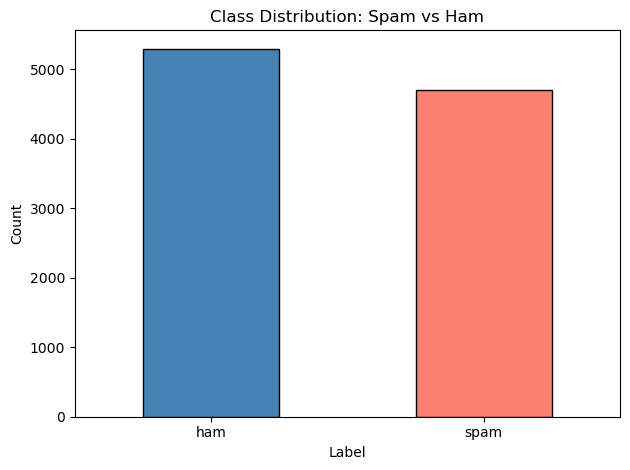

In [25]:
# Check the distribution of classes (Spam vs Ham)
print("Class distribution:")
print(df.iloc[:, -2].value_counts())

# Visualize class distribution
df.iloc[:, -2].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution: Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Cell 4 — Data Preprocessing

In [37]:

text_col  = 'text'   # column containing the email text
label_col = 'label'   # column containing spam/ham labels

print(f"Text column  : '{text_col}'")
print(f"Label column : '{label_col}'")


# Drop rows where either text or label is missing

df = df[[text_col, label_col]].dropna()
print(f"\nRows after dropping nulls: {df.shape[0]}")



Text column  : 'text'
Label column : 'label'

Rows after dropping nulls: 9989


---
## Train / Test Split

In [27]:
# Split data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y                      #random state fixes the random shuffle so you get the **same split every time** you run the code. Without this, the split would be different on each run,
)                                                                         #ensures the **class proportions are preserved** in both splits. For example, if your original data is 70% Ham / 30% Spam, both `y_train` and `y_test` will also be ~70% Ham / 30% Spam. Without this, you could accidentally get an imbalanced split by chance.

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 7991
Testing  samples : 1998


---
## Text Vectorization
> Converting raw text into numerical features that the model can understand.

In [28]:
# CountVectorizer: counts how many times each word appears


count_vec = CountVectorizer(stop_words='english')
X_train_count = count_vec.fit_transform(X_train)  # fit on train, transform train
X_test_count  = count_vec.transform(X_test)        # only transform test (no fit!)

print("CountVectorizer feature matrix shape (train):", X_train_count.shape)

# TF-IDF: balances word frequency with how unique the word is across documents 

#TF (Term Frequency) — How often does a word appear in this specific email?
  
#IDF (Inverse Document Frequency) — How rare is this word across ALL emails?
# TF-IDF = TF × IDF



tfidf_vec = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print("TF-IDF Vectorizer feature matrix shape (train):", X_train_tfidf.shape)

# 84,570 unique words across all of them.

CountVectorizer feature matrix shape (train): (7991, 84570)
TF-IDF Vectorizer feature matrix shape (train): (7991, 84570)


---
## Train Both Naive Bayes Models

In [29]:
#  Model 1: Multinomial Naive Bayes (works well with word counts) 
mnb_count = MultinomialNB()
mnb_count.fit(X_train_count, y_train)   # train on CountVectorizer features

mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)   # train on TF-IDF features

# Model 2: Bernoulli Naive Bayes (works with binary: word present/absent) 
bnb_count = BernoulliNB()
bnb_count.fit(X_train_count, y_train)

bnb_tfidf = BernoulliNB()
bnb_tfidf.fit(X_train_tfidf, y_train)

print("All 4 models trained successfully!")

All 4 models trained successfully!


---
## Predictions

In [30]:
# Generate predictions on the test set for each model

y_pred_mnb_count = mnb_count.predict(X_test_count)
y_pred_mnb_tfidf = mnb_tfidf.predict(X_test_tfidf)
y_pred_bnb_count = bnb_count.predict(X_test_count)
y_pred_bnb_tfidf = bnb_tfidf.predict(X_test_tfidf)

print("Predictions generated for all 4 model-vectorizer combinations.")

Predictions generated for all 4 model-vectorizer combinations.


---
## Model Evaluation (Metrics)

In [31]:

def evaluate_model(name, y_true, y_pred):
    print(f"{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

# Evaluate all models
evaluate_model("MultinomialNB  + CountVectorizer", y_test, y_pred_mnb_count)
evaluate_model("MultinomialNB  + TF-IDF",          y_test, y_pred_mnb_tfidf)
evaluate_model("BernoulliNB    + CountVectorizer", y_test, y_pred_bnb_count)
evaluate_model("BernoulliNB    + TF-IDF",          y_test, y_pred_bnb_tfidf)

  Model: MultinomialNB  + CountVectorizer
  Accuracy  : 0.9620
  Precision : 0.9635
  Recall    : 0.9620
  F1-Score  : 0.9620

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.94      0.96      1059
        spam       0.93      0.99      0.96       939

    accuracy                           0.96      1998
   macro avg       0.96      0.96      0.96      1998
weighted avg       0.96      0.96      0.96      1998

  Model: MultinomialNB  + TF-IDF
  Accuracy  : 0.9710
  Precision : 0.9714
  Recall    : 0.9710
  F1-Score  : 0.9710

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.96      0.97      1059
        spam       0.96      0.98      0.97       939

    accuracy                           0.97      1998
   macro avg       0.97      0.97      0.97      1998
weighted avg       0.97      0.97      0.97      1998

  Model: BernoulliNB    + CountVectorizer
  Accuracy 

---
## Confusion Matrices (Visualized)

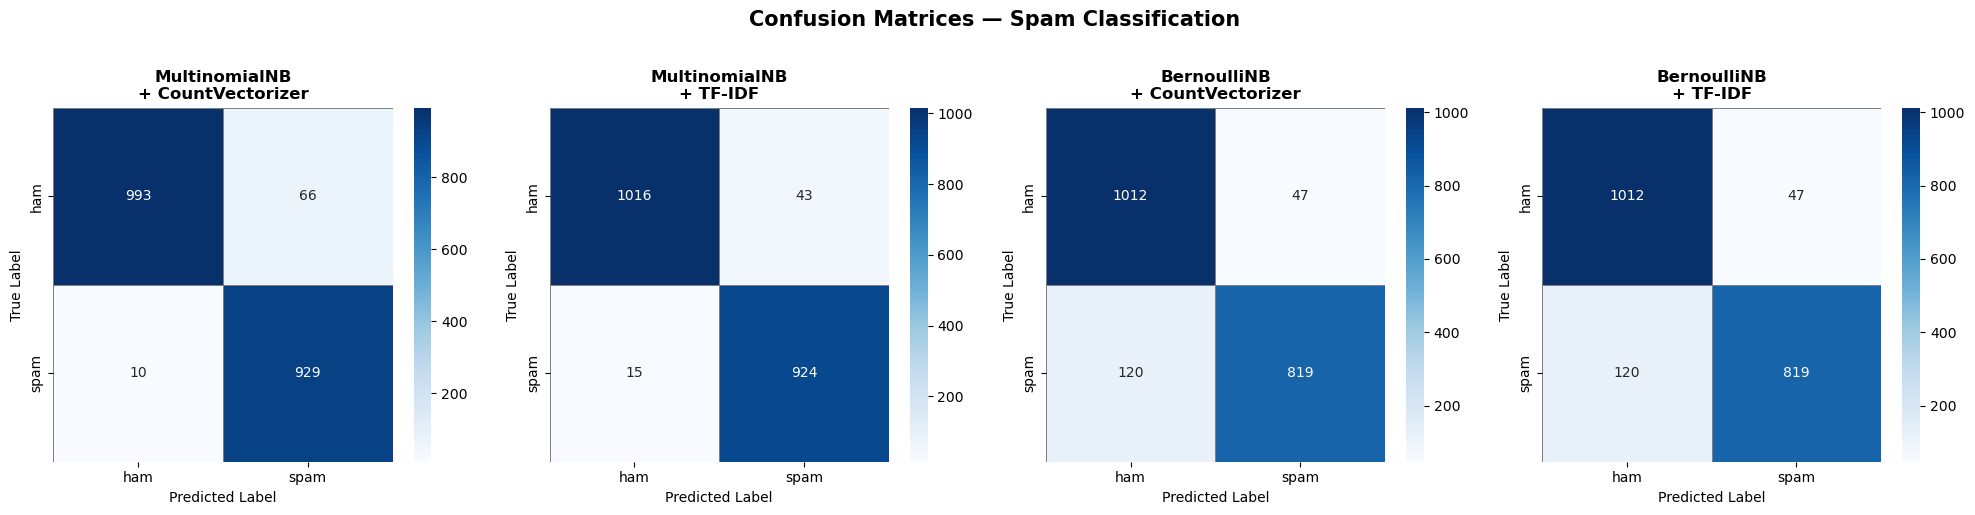

In [32]:

models = [
    ("MultinomialNB\n+ CountVectorizer", y_pred_mnb_count),
    ("MultinomialNB\n+ TF-IDF",          y_pred_mnb_tfidf),
    ("BernoulliNB\n+ CountVectorizer",   y_pred_bnb_count),
    ("BernoulliNB\n+ TF-IDF",            y_pred_bnb_tfidf),
]

labels = sorted(y_test.unique())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax,
        linewidths=0.5, linecolor='gray'
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Spam Classification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Performance Comparison Table

In [33]:

results = []

for name, y_pred in models:
    clean_name = name.replace('\n', ' ')
    results.append({
        'Model': clean_name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\n===== Model Comparison Summary =====")
display(results_df.style.highlight_max(axis=0, color='lightgreen'))


===== Model Comparison Summary =====


,Accuracy,Precision,Recall,F1-Score
Model,,,,
MultinomialNB + CountVectorizer,0.962000,0.963500,0.962000,0.962000
MultinomialNB + TF-IDF,0.971000,0.971400,0.971000,0.971000
BernoulliNB + CountVectorizer,0.916400,0.918300,0.916400,0.916100
BernoulliNB + TF-IDF,0.916400,0.918300,0.916400,0.916100


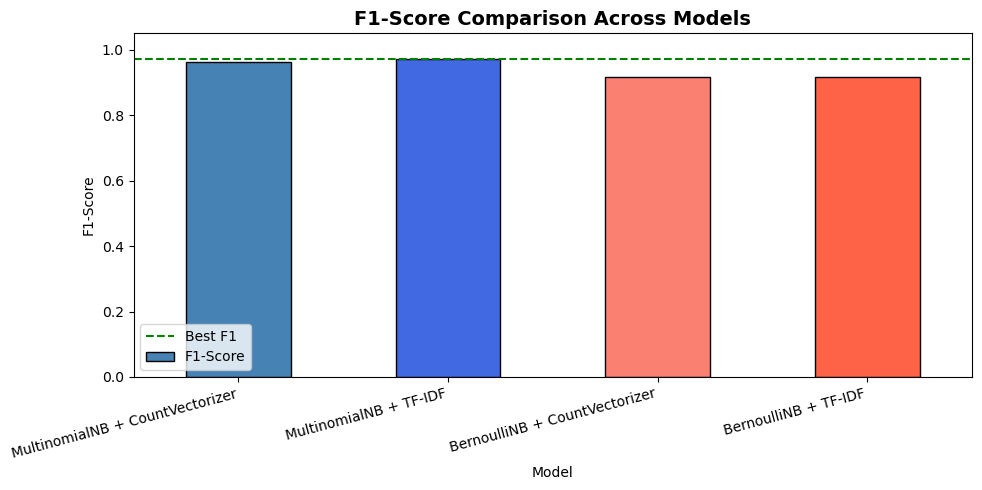

In [34]:

results_df['F1-Score'].plot(
    kind='bar', color=['steelblue', 'royalblue', 'salmon', 'tomato'],
    edgecolor='black', figsize=(10, 5)
)
plt.title('F1-Score Comparison Across Models', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.axhline(y=results_df['F1-Score'].max(), color='green', linestyle='--', label='Best F1')
plt.legend()
plt.tight_layout()
plt.show()